# Change-Point Hyperparameter Sweep

This notebook sweeps `ruptures` PELT hyperparameters over the saved system-eval window forecasts in `results/evaluation/` without rerunning the forecast models.

It writes sweep outputs to `results/evaluation/cp_hyperparameter_sweep/` and saves the summary figure to `results/plots/`.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)
print('Python:', sys.executable)


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
Python: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python


In [2]:
MODELS = ['lstm', 'deepar', 'chronos2']
DATASET_PATH = ROOT / 'data' / 'data_1to7.csv'
INPUT_DIR = ROOT / 'results' / 'evaluation'
SWEEP_DIR = ROOT / 'results' / 'evaluation' / 'cp_hyperparameter_sweep'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

CP_MODELS = ['normal']
CP_PENALTIES = [10, 15, 20]
CP_MIN_SIZES = [8, 10, 12]
CP_JUMPS = [1]
TOLERANCE = 3
COVERAGE_TARGET = 0.95

cmd = [
    sys.executable,
    str(ROOT / 'src' / 'cp_sweep.py'),
    '--models', ','.join(MODELS),
    '--data-path', str(DATASET_PATH),
    '--input-dir', str(INPUT_DIR),
    '--output-dir', str(SWEEP_DIR),
    '--cp-models', ','.join(CP_MODELS),
    '--cp-penalties', ','.join(str(x) for x in CP_PENALTIES),
    '--cp-min-sizes', ','.join(str(x) for x in CP_MIN_SIZES),
    '--cp-jumps', ','.join(str(x) for x in CP_JUMPS),
    '--tolerance', str(TOLERANCE),
    '--coverage-target', str(COVERAGE_TARGET),
]

print('Grid size per model:', len(CP_MODELS) * len(CP_PENALTIES) * len(CP_MIN_SIZES) * len(CP_JUMPS))
print('Running:', ' '.join(cmd))
subprocess.run(cmd, cwd=ROOT, check=True)

SUMMARY_PATH = SWEEP_DIR / 'cp_sweep_summary.csv'
BEST_PATH = SWEEP_DIR / 'cp_sweep_best_configs.csv'
MANIFEST_PATH = SWEEP_DIR / 'cp_sweep_manifest.json'
print('Summary:', SUMMARY_PATH)
print('Best configs:', BEST_PATH)
print('Manifest:', MANIFEST_PATH)


Grid size per model: 9
Running: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/bin/python /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/src/cp_sweep.py --models lstm,deepar,chronos2 --data-path /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv --input-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation --output-dir /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep --cp-models normal --cp-penalties 10,15,20 --cp-min-sizes 8,10,12 --cp-jumps 1 --tolerance 3 --coverage-target 0.95


/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/.venv/lib/python3.13/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


Saved sweep summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_summary.csv
Saved best configs: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_best_configs.csv
Saved manifest: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_manifest.json
Summary: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_summary.csv
Best configs: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_best_configs.csv
Manifest: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/evaluation/cp_hyperparameter_sweep/cp_sweep_manifest.json


In [3]:
summary_df = pd.read_csv(SUMMARY_PATH)
best_df = pd.read_csv(BEST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text())

display(summary_df.head())
display(best_df[['model', 'selection_rule', 'cp_model', 'cp_penalty', 'cp_min_size', 'cp_jump', 'MAE_CP', 'tolerance_hit_rate', 'coverage_rate', 'sharpness', 'delta_MAE_CP', 'delta_tolerance_hit_rate', 'delta_coverage_rate', 'delta_sharpness']].sort_values(['model', 'selection_rule']).reset_index(drop=True))


,model,dataset_path,cp_model,cp_penalty,cp_min_size,cp_jump,num_windows_total,MAE_CP,tolerance,tolerance_hit_rate,...,tau_true_horizon_rate,baseline_MAE_CP,baseline_tolerance_hit_rate,baseline_coverage_rate,baseline_sharpness,delta_MAE_CP,delta_tolerance_hit_rate,delta_coverage_rate,delta_sharpness,coverage_gap
0,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,normal,10.0,8,1,4300,6.149767,3,0.467209,...,0.013953,10.584186,0.31186,0.956005,3.770255,-4.434419,0.155349,0.000357,-0.188736,0.006362
1,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,normal,15.0,8,1,4300,9.800233,3,0.340698,...,0.058140,10.584186,0.31186,0.956005,3.770255,-0.783953,0.028837,-0.002453,-0.155215,0.003551
2,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,normal,20.0,8,1,4300,13.936977,3,0.253256,...,0.150465,10.584186,0.31186,0.956005,3.770255,3.352791,-0.058605,-0.004189,0.028952,0.001815
3,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,normal,10.0,10,1,4300,6.937674,3,0.406512,...,0.023953,10.584186,0.31186,0.956005,3.770255,-3.646512,0.094651,0.000875,-0.037350,0.006879
4,chronos2,/Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repo...,normal,15.0,10,1,4300,10.584186,3,0.311860,...,0.090465,10.584186,0.31186,0.956005,3.770255,0.000000,0.000000,0.000000,0.000000,0.006005


,model,selection_rule,cp_model,cp_penalty,cp_min_size,cp_jump,MAE_CP,tolerance_hit_rate,coverage_rate,sharpness,delta_MAE_CP,delta_tolerance_hit_rate,delta_coverage_rate,delta_sharpness
0,chronos2,best_mae_cp,normal,10.0,8,1,6.149767,0.467209,0.956362,3.581518,-4.434419,0.155349,0.000357,-0.188736
1,chronos2,best_tolerance_hit_rate,normal,10.0,8,1,6.149767,0.467209,0.956362,3.581518,-4.434419,0.155349,0.000357,-0.188736
2,chronos2,closest_coverage_to_0.95,normal,20.0,8,1,13.936977,0.253256,0.951815,3.799207,3.352791,-0.058605,-0.004189,0.028952
3,deepar,best_mae_cp,normal,10.0,8,1,5.866977,0.502093,0.947409,2.229428,-4.018837,0.124419,0.001343,0.186497
4,deepar,best_tolerance_hit_rate,normal,10.0,8,1,5.866977,0.502093,0.947409,2.229428,-4.018837,0.124419,0.001343,0.186497
5,deepar,closest_coverage_to_0.95,normal,10.0,10,1,6.277442,0.491395,0.948711,2.241704,-3.608372,0.113721,0.002646,0.198773
6,lstm,best_mae_cp,normal,10.0,8,1,6.347442,0.494651,0.976987,4.200704,-3.841395,0.161395,0.000070,0.303923
7,lstm,best_tolerance_hit_rate,normal,10.0,8,1,6.347442,0.494651,0.976987,4.200704,-3.841395,0.161395,0.000070,0.303923
8,lstm,closest_coverage_to_0.95,normal,10.0,10,1,6.813023,0.441860,0.975649,4.041803,-3.375814,0.108605,-0.001268,0.145022


Saved plot: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/cp_hyperparameter_sweep_heatmaps.png


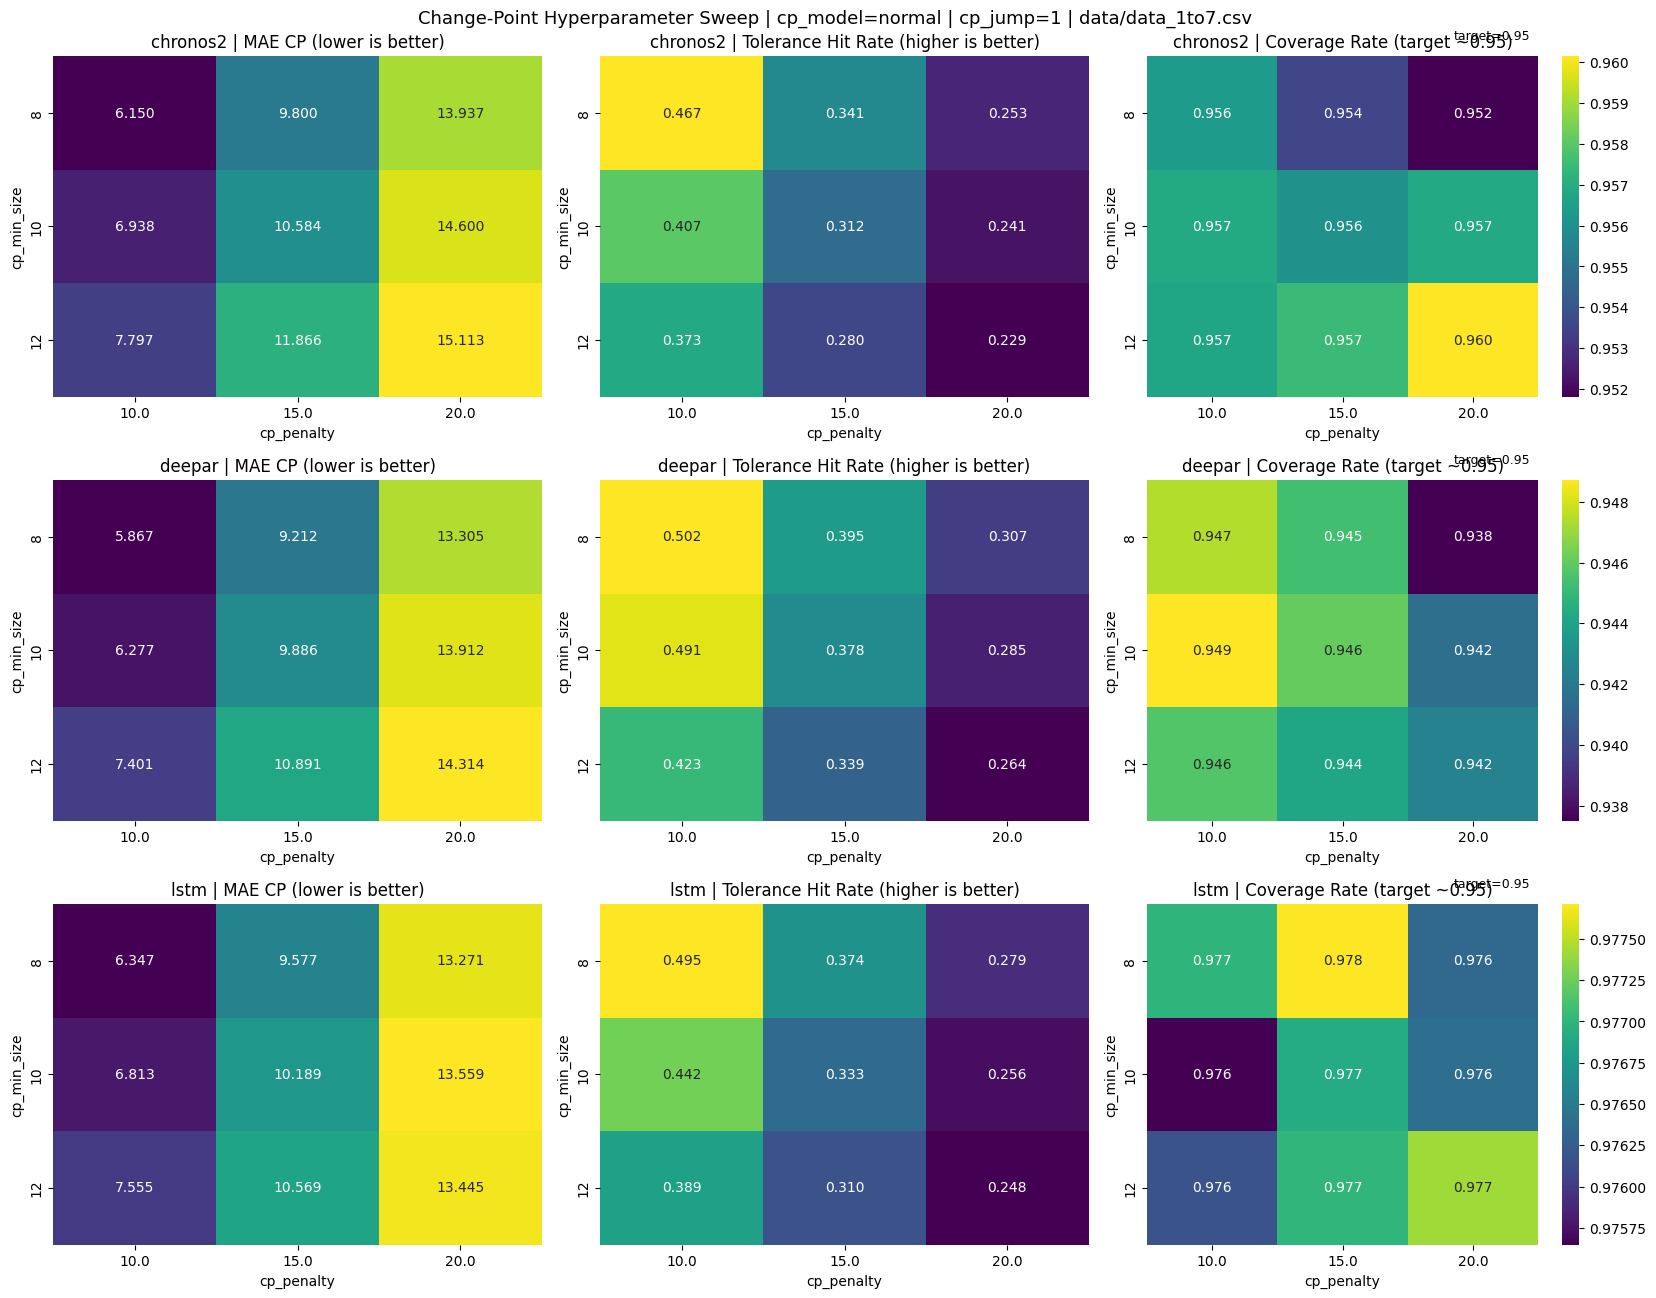

In [4]:
plot_cp_model = CP_MODELS[0]
plot_cp_jump = CP_JUMPS[0]
plot_df = summary_df[(summary_df['cp_model'] == plot_cp_model) & (summary_df['cp_jump'] == plot_cp_jump)].copy()
if plot_df.empty:
    raise RuntimeError('No sweep rows available for the selected cp_model/cp_jump.')

metric_specs = [
    ('MAE_CP', 'MAE CP (lower is better)', False),
    ('tolerance_hit_rate', 'Tolerance Hit Rate (higher is better)', True),
    ('coverage_rate', 'Coverage Rate (target ~0.95)', True),
]
models = plot_df['model'].drop_duplicates().tolist()
fig, axes = plt.subplots(len(models), len(metric_specs), figsize=(5.6 * len(metric_specs), 4.4 * len(models)), squeeze=False)

for row_idx, model_name in enumerate(models):
    model_df = plot_df[plot_df['model'] == model_name]
    for col_idx, (metric, title, annotate_target) in enumerate(metric_specs):
        ax = axes[row_idx][col_idx]
        pivot = model_df.pivot(index='cp_min_size', columns='cp_penalty', values=metric).sort_index().sort_index(axis=1)
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax, cbar=(col_idx == len(metric_specs) - 1))
        ax.set_title(f'{model_name} | {title}')
        ax.set_xlabel('cp_penalty')
        ax.set_ylabel('cp_min_size')
        if metric == 'coverage_rate':
            ax.text(0.98, 1.04, 'target=0.95', transform=ax.transAxes, ha='right', va='bottom', fontsize=9)

fig.suptitle(
    f'Change-Point Hyperparameter Sweep | cp_model={plot_cp_model} | cp_jump={plot_cp_jump} | data/data_1to7.csv',
    fontsize=13,
)
plt.tight_layout()
plot_path = PLOTS_DIR / 'cp_hyperparameter_sweep_heatmaps.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
print('Saved plot:', plot_path)
plt.show()
